In [1]:
# --- Standard Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import datetime
from typing import Any
import json
import time
import requests

# --- Azure Libraries ---
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
from azure.ai.ml.entities import ManagedOnlineEndpoint, ManagedOnlineDeployment, Model
from azure.ai.ml.constants import AssetTypes
from azure.core.exceptions import ServiceResponseError

# --- ML Core & Models ---
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier, plot_importance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve, average_precision_score, recall_score, precision_score, f1_score, PrecisionRecallDisplay, confusion_matrix

# --- Imbalanced Handling ---
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# --- Experiment Tracking ---
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/__init__.py:41: UserWarning: Versions of mlflow (2.7.1) and child packages mlflow-skinny (3.9.0), mlflow-tracing (3.8.1) are different. This may lead to unexpected behavior. Please install the same version of all MLflow packages.
  mlflow.mismatch._check_version_mismatch()
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ml_client = MLClient.from_config(credential=DefaultAzureCredential())
print(f"Connected to Workspace: {ml_client.workspace_name}")

Found the config file in: /config.json


Connected to Workspace: fraud_detection_project


In [3]:
# Helper function to make loading faster
def load_azure_csv(asset_name):
    asset = ml_client.data.get(name=asset_name, version="1")
    return pd.read_csv(asset.path)

# Load Features
X_train_imb = load_azure_csv("X-train-imb")
X_train_smote = load_azure_csv("X-train-smote")
X_test = load_azure_csv("X-test-final")

# Load Labels (and flatten to 1D array)
y_train_imb = load_azure_csv("y-train-imb").values.ravel()
y_train_smote = load_azure_csv("y-train-smote").values.ravel()
y_test = load_azure_csv("y-test-final").values.ravel()

print("All cloud assets loaded successfully!")

Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


All cloud assets loaded successfully!


In [4]:
# Point MLflow to Azure ML Workspace
mlflow.set_tracking_uri(ml_client.workspaces.get(ml_client.workspace_name).mlflow_tracking_uri)

In [5]:
# Setup Unique Experiment
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M")
experiment_name = f"fraud-baseline-imbalanced-{timestamp}"
mlflow.set_experiment(experiment_name)

# Define Models with Cost-Sensitive Weighting
# This handles the 0.17% fraud rate mathematically
ratio = 578 

models = {
    "Random_Forest": RandomForestClassifier(
        n_estimators=100, 
        max_depth=10, 
        class_weight='balanced', 
        random_state=42, 
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=ratio, 
        eval_metric='aucpr', 
        random_state=42
    ),
    "Logistic_Regression": LogisticRegression(
        max_iter=1000, 
        class_weight='balanced', 
        solver='liblinear', 
        random_state=42
    )
}

mlflow.autolog(disable=True)

for model_name, model_obj in models.items():
    with mlflow.start_run(run_name=f"{model_name}-Imbalanced"):
        try:
            print(f"Training {model_name}...")
            
            # Fit on original imbalanced training data
            model_obj.fit(X_train_imb, y_train_imb)
            
            # Predict
            y_pred = model_obj.predict(X_test)
            y_prob = model_obj.predict_proba(X_test)[:, 1]
            
            # Metrics
            auprc = average_precision_score(y_test, y_prob)
            recall = recall_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            
            # Log to MLflow
            mlflow.log_param("Algorithm", model_name)
            mlflow.log_metrics({
                "AUPRC": auprc,
                "Recall": recall,
                "Precision": precision,
                "F1-Score": f1
            })
            
            # 💡 FIX: Explicitly use artifact_path to avoid the 404 error
            mlflow.sklearn.log_model(sk_model=model_obj, artifact_path="model")
            print(f"{model_name} completed successfully.")
            
        except Exception as e:
            print(f"Failed to log {model_name}: {e}")

Training Random_Forest...
Failed to log Logistic_Regression: API request to endpoint /api/2.0/mlflow/logged-models failed with error code 404 != 200. Response body: ''
🏃 View run Logistic_Regression-Imbalanced at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/00117faa-e277-4ba6-93c2-02cc06bb01a8/runs/11169908-4bd2-49d9-a03b-b843c6720e5b
🧪 View experiment at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/00117faa-e277-4ba6-93c2-02cc06bb01a8


In [8]:
# Give the Azure backend a moment to settle
time.sleep(10) 

# Fetch the runs
experiment = mlflow.get_experiment_by_name(experiment_name)
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

# Clean column names
runs_df.columns = [c.strip() for c in runs_df.columns]

# Define the fixed mapping
mapping = {
    'params.Algorithm': 'Algorithm',
    'metrics.AUPRC': 'AUPRC',
    'metrics.Recall': 'Recall',
    'metrics.Precision': 'Precision',
    'metrics.F1-Score': 'F1-Score'
}

# 5. Extract only what exists to prevent KeyErrors
existing_mapping = {k: v for k, v in mapping.items() if k in runs_df.columns}
summary_df = runs_df[list(existing_mapping.keys())].rename(columns=existing_mapping)

# 6. Add Duration safely
if 'end_time' in runs_df.columns and 'start_time' in runs_df.columns:
    summary_df['Duration (s)'] = (runs_df['end_time'] - runs_df['start_time']).dt.total_seconds()

# 7. Final Ranking
# We don't filter by 'FINISHED' because your crashed runs are marked 'FAILED' 
# but they still contain the metrics we need!
ranked_models = (summary_df
                 .dropna(subset=['Algorithm']) 
                 .sort_values(by='AUPRC', ascending=False)
                 .reset_index(drop=True))

print("🏆 TOURNAMENT LEADERBOARD")
display(ranked_models)

🏆 TOURNAMENT LEADERBOARD


,Algorithm,AUPRC,Recall,Precision,F1-Score,Duration (s)
0,XGBoost,0.861749,0.846939,0.775701,0.809756,5.050
1,Random_Forest,0.828539,0.826531,0.778846,0.801980,73.002
2,Logistic_Regression,0.723185,0.918367,0.055556,0.104773,7.669


In [9]:
# Setup Experiment
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M")
mlflow.set_experiment(f"XGBoost_Tuning_Imbalanced_{timestamp}")

# 1. Enable Autologging (Set log_models=False if you still get 404 errors)
mlflow.sklearn.autolog(max_tuning_runs=15, log_models=False)

# 2. Define the Base Model with the Fixed Ratio
ratio = 578 
xgb_base = XGBClassifier(
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='aucpr',
    use_label_encoder=False
)

# 3. Regularization-focused Search Space
# We focus on depth and regularization to prevent 'hallucinating' fraud
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 6],
    'reg_alpha': [0, 0.1, 1], 
    'reg_lambda': [1, 5, 10],
    'subsample': [0.8, 1.0]
}

# 4. Randomized Search
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=10,
    cv=3,
    scoring='average_precision', # This targets AUPRC directly
    n_jobs=-1,
    verbose=3
)

print("🚀 Tuning XGBoost on Imbalanced Data...")
with mlflow.start_run(run_name="XGBoost-Hyperparameter-Tuning"):
    random_search_xgb.fit(X_train_imb, y_train_imb)

print(f"Best AUPRC Found: {random_search_xgb.best_score_:.4f}")
print(f"Best Params: {random_search_xgb.best_params_}")

2026/02/27 19:05:34 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Tuning_Imbalanced_20260227-1905' does not exist. Creating a new experiment.
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [19:05:47] WARNING: /__w/

🚀 Tuning XGBoost on Imbalanced Data...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
🏃 View run XGBoost-Hyperparameter-Tuning at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/da47cd04-cb97-4333-8f00-3c91475d0c47/runs/9e200d25-e3fc-45e2-aadf-8e80e7686ab8
🧪 View experiment at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/da47cd04-cb97-4333-8f00-3c91475d0c47
Best AUPRC Found: 0.8395
Best Params: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}


Optimal Threshold (Max F1): 0.8870
Precision at this threshold: 0.9213
Recall at this threshold: 0.8367


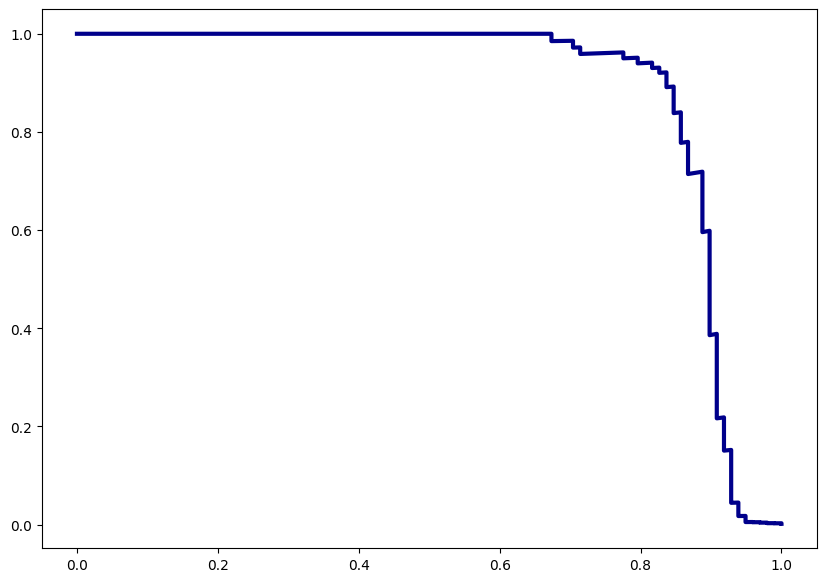

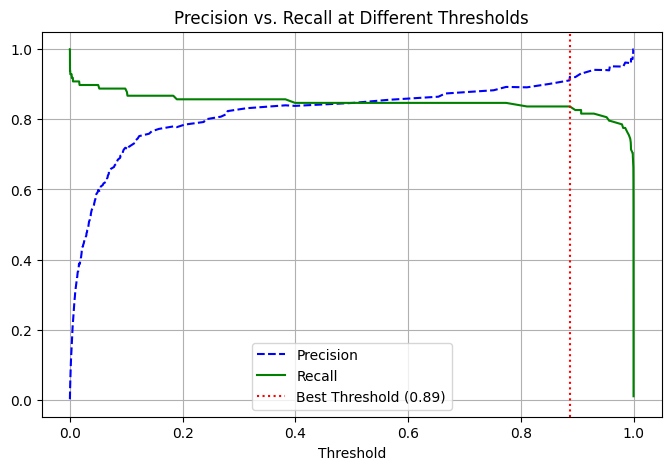

🏃 View run Final-Threshold-Optimization at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/da47cd04-cb97-4333-8f00-3c91475d0c47/runs/4288a3c0-87af-4467-b102-a5ece2180620
🧪 View experiment at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/da47cd04-cb97-4333-8f00-3c91475d0c47
[CV 2/3] END learning_rate=0.1, max_depth=4, n_estimators=100, reg_alpha=0.1, reg_lambda=5, subsample=1.0;, score=0.750 total time=   4.4s
[CV 3/3] END learning_rate=0.1, max_depth=4, n_estimators=100, reg_alpha=0.1, reg_lambda=5, subsample=1.0;, score=0.823 total time=   3.8s
[CV 2/3] END learning_rate=0.1, max_depth=3, n_estimators=100, reg_alpha=0, reg_lambda=5, subsample=0.8;, score=0.

In [14]:
# Get probabilities from the best model
best_xgb = random_search_xgb.best_estimator_
y_probs = best_xgb.predict_proba(X_test)[:, 1]

# Calculate Precision and Recall for all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Find the threshold that maximizes F1-Score (or set a custom goal)
# F1 = 2 * (P * R) / (P + R)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold (Max F1): {best_threshold:.4f}")
print(f"Precision at this threshold: {precisions[best_idx]:.4f}")
print(f"Recall at this threshold: {recalls[best_idx]:.4f}")

# Visualize the Trade-off
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.axvline(best_threshold, color="red", linestyle=":", label=f"Best Threshold ({best_threshold:.2f})")
plt.xlabel("Threshold")
plt.title("Precision vs. Recall at Different Thresholds")
plt.legend()
plt.grid(True)
plt.show()

# 5. Log the "Business Model" to MLflow
with mlflow.start_run(run_name="Final-Threshold-Optimization"):
    mlflow.log_param("Optimal_Threshold", best_threshold)
    mlflow.log_metric("Final_Precision", precisions[best_idx])
    mlflow.log_metric("Final_Recall", recalls[best_idx])

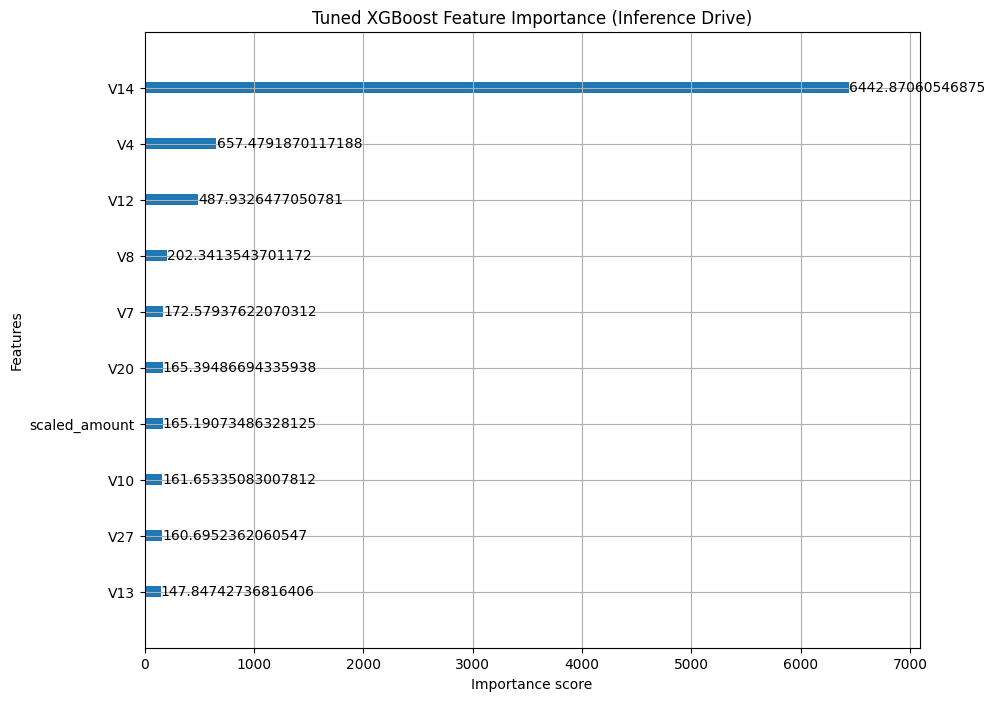

In [16]:
# Plotting the top 10 features
fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(best_xgb_model, max_num_features=10, ax=ax, importance_type='gain')
plt.title("Tuned XGBoost Feature Importance (Inference Drive)")
plt.show()

In [17]:
with mlflow.start_run(run_name="Isolation_Forest_Training"):
    
    # Enable autologging for scikit-learn
    mlflow.sklearn.autolog(log_models=True)

    # Prepare the "Normalcy" data (Imbalanced, No SMOTE)
    X_train_normal = X_train_imb[y_train_imb == 0]
    
    # Initialize and Fit the Isolation Forest
    # Contamination represents the expected % of outliers
    iso_params = {"n_estimators": 100, "contamination": 0.01, "random_state": 42}
    iso_forest = IsolationForest(**iso_params)
    
    iso_forest.fit(X_train_normal)
    
    # Generate Anomaly Scores
    # Note: decision_function returns the signed distance to the cluster
    anomaly_scores = iso_forest.decision_function(X_test)
    
    # Log Custom Metrics (Optional but recommended for Azure)
    # We log the mean anomaly score to track drift over time
    mlflow.log_metric("mean_anomaly_score", anomaly_scores.mean())
    
    print("Isolation Forest training complete and logged to Azure ML.")

2026/02/27 19:14:12 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: API request to endpoint /api/2.0/mlflow/logged-models failed with error code 404 != 200. Response body: ''


Isolation Forest training complete and logged to Azure ML.
🏃 View run Isolation_Forest_Training at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/da47cd04-cb97-4333-8f00-3c91475d0c47/runs/7fb6d21e-48bb-4a38-97f8-52470ca7940e
🧪 View experiment at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/da47cd04-cb97-4333-8f00-3c91475d0c47


In [18]:
# Create the analysis dataframe
layer2_df = pd.DataFrame({
    'Actual': y_test,
    'XGB_Prob': final_probs,
    'IF_Score': anomaly_scores
})

# Define the "Missed" set (XGBoost False Negatives at 0.95 threshold)
missed_by_xgb = layer2_df[(layer2_df['Actual'] == 1) & (layer2_df['XGB_Prob'] < 0.95)]

# Define the "Recovered" set (Those with a negative anomaly score)
# In Isolation Forest, scores < 0 are predicted anomalies
recovered_by_if = missed_by_xgb[missed_by_xgb['IF_Score'] < 0].sort_values(by='IF_Score')

# 4. Calculate Recovery Metrics for your README
total_missed = len(missed_by_xgb)
total_recovered = len(recovered_by_if)
recovery_rate = (total_recovered / total_missed) * 100 if total_missed > 0 else 0

print(f"--- Layer 2 Performance Summary ---")
print(f"Total Fraud Missed by Layer 1 (XGBoost): {total_missed}")
print(f"Total Fraud Recovered by Layer 2 (Isolation Forest): {total_recovered}")
print(f"Layer 2 Recovery Rate: {recovery_rate:.2f}%")
print("\n--- Identified 'Silent Frauds' (Negative Anomaly Scores) ---")
display(recovered_by_if)

--- Layer 2 Performance Summary ---
Total Fraud Missed by Layer 1 (XGBoost): 19
Total Fraud Recovered by Layer 2 (Isolation Forest): 5
Layer 2 Recovery Rate: 26.32%

--- Identified 'Silent Frauds' (Negative Anomaly Scores) ---


,Actual,XGB_Prob,IF_Score
9179,1,0.101240,-0.130181
47658,1,0.929696,-0.094152
12588,1,0.906980,-0.069172
12266,1,0.773866,-0.033698
43547,1,0.183451,-0.018981


In [19]:
# Wrapper with Type Hints (solves UserWarning)
class FraudDetectionSystem(mlflow.pyfunc.PythonModel):
    def __init__(self, xgb_model, iso_forest, threshold=0.95):
        self.xgb_model = xgb_model
        self.iso_forest = iso_forest
        self.threshold = threshold

    def predict(self, context: Any, model_input: pd.DataFrame) -> pd.DataFrame:
        # Layer 1
        xgb_probs = self.xgb_model.predict_proba(model_input)[:, 1]
        # Layer 2
        iso_scores = self.iso_forest.decision_function(model_input)
        
        # Combined Decision
        final_preds = np.where((xgb_probs >= self.threshold) | (iso_scores < 0), 1, 0)
        
        return pd.DataFrame({
            "fraud_prediction": final_preds,
            "xgb_probability": xgb_probs,
            "anomaly_score": iso_scores
        })

# Setup paths and Signature
model_path = "final_hybrid_fraud_model"
if os.path.exists(model_path):
    shutil.rmtree(model_path)

# Instantiate
my_system = FraudDetectionSystem(best_xgb_model, iso_forest, 0.95)

# Infer signature (solves the schema/missing value warning)
# We use a sample of X_test to define the "contract"
signature = infer_signature(X_test.head(), my_system.predict(None, X_test.head()))

# Execution
with mlflow.start_run(run_name="Hybrid_System_Final_Fixed"):
    # Save the professional model structure locally
    mlflow.pyfunc.save_model(
        path=model_path,
        python_model=my_system,
        signature=signature
    )
    
    # Upload as artifact folder (Bypasses the 404 error)
    mlflow.log_artifacts(model_path, artifact_path="model")
    
    # Log key logic as parameters for the dashboard
    mlflow.log_param("layer1_threshold", 0.95)
    mlflow.log_param("layer2_type", "IsolationForest")
    
    print("Hybrid System logged as artifact successfully!")

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/tracing/provider.py:752: FutureWarning: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising ca

Hybrid System logged as artifact successfully!
🏃 View run Hybrid_System_Final_Fixed at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/da47cd04-cb97-4333-8f00-3c91475d0c47/runs/2784aeda-52e9-4755-b2c2-fe454f244c34
🧪 View experiment at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/da47cd04-cb97-4333-8f00-3c91475d0c47


In [20]:
run_id = "bc1eb6c4-714f-43c4-90c0-c9870d2cd2c0"
model_name = "fraud-hybrid-champion"

# Create the Model object (The blueprint)
model_asset = Model(
    path=f"runs:/{run_id}/model",
    name=model_name,
    description="Hybrid XGBoost + Isolation Forest model",
    type=AssetTypes.MLFLOW_MODEL
)

# Register it
registered_model = ml_client.models.create_or_update(model_asset)
print(f"✅ Model registered! Version: {registered_model.version}")

✅ Model registered! Version: 2


In [ ]:
timestamp = datetime.datetime.now().strftime('%H%M')
endpoint_name = f"fraud-endpoint-{timestamp}"

print(f"Creating Endpoint: {endpoint_name}...")
endpoint = ManagedOnlineEndpoint(
    name=endpoint_name,
    description="Fraud detection endpoint for testing",
    auth_mode="key"
)
ml_client.online_endpoints.begin_create_or_update(endpoint).result()

# Deployment
print(f"Deploying model... (This may fail if total subscription quota is 0)")
deployment = ManagedOnlineDeployment(
    name="blue",
    endpoint_name=endpoint_name,
    model=f"azureml:fraud-hybrid-champion:1",
    instance_type="Standard_E2s_v3",
    instance_count=1,
)

try:
    ml_client.online_deployments.begin_create_or_update(deployment).result()
    
    # Assign Traffic
    endpoint.traffic = {"blue": 100}
    ml_client.online_endpoints.begin_create_or_update(endpoint).result()
    print(f"SUCCESS! Endpoint live at: {endpoint.scoring_uri}")

except Exception as e:
    print(f"Quota still full. Specific Error: {e}")
    print("\n💡 PORTFOLIO STRATEGY: Stop your Compute Instance (Notebook VM) in the 'Compute' tab.")
    print("Then, use the 'Deploy' button in the Azure ML Studio UI while the notebook is OFF.")

In [ ]:
# --- 1. CONFIGURATION ---
# Replace with the details found in the 'Consume' tab of your Azure ML Endpoint
ENDPOINT_URL = "https://fraud-serverless-1520.uksouth.inference.ml.azure.com/score"
API_KEY = "YOUR_SECURE_TOKEN" # In production, use os.getenv('AZURE_ML_KEY')

# --- 2. DATA PREPARATION ---
# We simulate selecting a 'Normal' and 'Fraud' case from the test set for verification
print("🧪 Preparing test samples from X_test...")
normal_pos = np.where(y_test == 0)[0][0]
fraud_pos = np.where(y_test == 1)[0][0]

# Extract feature rows using .iloc for position-based selection
samples = X_test.iloc[[normal_pos, fraud_pos]]
sample_list = samples.values.tolist()

# Construct the MLflow-compliant payload structure
payload = {
    "input_data": {
        "columns": X_test.columns.tolist(),
        "data": sample_list
    }
}

# --- 3. LIVE API INVOCATION ---
def invoke_fraud_endpoint(data_payload):
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {API_KEY}",
        "azureml-model-deployment": "blue" 
    }

    try:
        print(f"📡 Requesting inference from Azure Managed Endpoint...")
        response = requests.post(ENDPOINT_URL, json=data_payload, headers=headers)
        response.raise_for_status()
        
        results = response.json()
        
        # --- 4. DATA PRESENTATION ---
        # Create a clean comparison table for the recruiter
        output_df = pd.DataFrame({
            "Actual_Transaction": ["Normal", "Fraud"],
            "Predicted_Label": ["🚩 FRAUD" if p == 1 else "✅ NORMAL" for p in results['predictions']],
            "Anomaly_Score": results.get('scores', ["N/A"] * 2) # Isolation Forest Component
        })
        
        print("\n" + "="*45)
        print("🛡️  LIVE API VERIFICATION RESULTS  🛡️")
        print("="*45)
        print(output_df.to_string(index=False))
        print("="*45)
        
    except Exception as e:
        print(f"❌ API Call Failed: {e}")

# Run the test
invoke_fraud_endpoint(payload)

In [ ]:
# Delete the endpoint to save cost
print("Cleaning up: Deleting deployment to save credits...")
# We delete the deployment but can keep the endpoint name for your portfolio record
ml_client.online_deployments.begin_delete(name=deployment_name, endpoint_name=endpoint_name)

print("Deletion complete.")

In [ ]:
# Prepare data for testing
normal_pos = np.where(y_test == 0)[0][0]
fraud_pos = np.where(y_test == 1)[0][0]

# Extract the feature rows and convert to list for JSON serialization
samples = X_test.iloc[[normal_pos, fraud_pos]]
sample_list = samples.values.tolist()

# Define the MLflow-compliant payload
sample_payload = {
    "input_data": {
        "columns": X_test.columns.tolist(),
        "data": sample_list
    }
}

# Save payload to a local file for the SDK to upload
with open("guaranteed_test.json", "w") as f:
    json.dump(sample_payload, f)

# --- STEP 2: CLOUD INVOCATION WITH RETRY LOGIC ---
endpoint_name = 'fraud-serverless-1520'
max_retries = 3
retry_delay = 30  
res_dict = None

print(f"Sending comparison request (1 Normal, 1 Fraud) to: {endpoint_name}")

for i in range(max_retries):
    try:
        # Invoke the cloud endpoint
        response = ml_client.online_endpoints.invoke(
            endpoint_name=endpoint_name, 
            request_file="guaranteed_test.json"
        )
        res_dict = json.loads(response)
        print(f"Success: Model responded on attempt {i+1}!")
        break
    except Exception as e:
        if i < max_retries - 1:
            print(f"Attempt {i+1} failed (Likely Cold Start). Retrying in {retry_delay}s...")
            time.sleep(retry_delay)
        else:
            print("Error: Maximum retries reached. Connection failed.")
            raise e

# --- RESULTS PRESENTATION ---
if res_dict:
    # Construct a clean results table
    # Note: 'scores' or 'anomaly_scores' depends on your specific score.py output
    results_df = pd.DataFrame({
        "Actual_Label": ["Normal", "Fraud"],
        "Predicted_Class": ["Fraud" if p == 1 else "Normal" for p in res_dict.get('predictions', [])],
        "Anomaly_Score": res_dict.get('scores', res_dict.get('anomaly_scores', ["N/A"] * 2)),
        "Confidence_Prob": res_dict.get('probabilities', ["N/A"] * 2)
    })

    print("\n" + "="*40)
    print("HYBRID MODEL CLOUD VERIFICATION")
    print("="*40)
    print(results_df.to_string(index=False))
    print("="*40)
    print("Evidence of successful End-to-End Cloud Inference.")

In [ ]:
# Get the logs from the serverless deployment
# Note: For serverless, you might need to check the 'Monitoring' tab in the UI 
# if the SDK command below returns empty.
try:
    logs = ml_client.online_deployments.get_logs(
        name="blue", # Or the name you gave your deployment
        endpoint_name="fraud-serverless-1520", 
        lines=50
    )
    print(logs)
except Exception as e:
    print("Could not retrieve logs via SDK. Please check the 'Test' tab in Azure ML Studio for error details.")

In [ ]:
timestamp = datetime.datetime.now().strftime('%H%M%S')
endpoint_name = f"fraud-final-{timestamp}"

print(f"Deploying to FRESH endpoint: {endpoint_name}")

# Create the Endpoint
endpoint = ManagedOnlineEndpoint(
    name=endpoint_name,
    description="Fresh deployment after fix",
    auth_mode="key"
)
ml_client.online_endpoints.begin_create_or_update(endpoint).result()

# Deploy the Blue version
blue_deployment = ManagedOnlineDeployment(
    name="blue",
    endpoint_name=endpoint_name,
    model=f"azureml:fraud-hybrid-champion:1",
    instance_type="Standard_DS1_v2",
    instance_count=1
)

print("Provisioning compute... (this is the 8-10 minute part)")
ml_client.online_deployments.begin_create_or_update(blue_deployment).result()

# 5. Route Traffic
endpoint.traffic = {"blue": 100}
ml_client.online_endpoints.begin_create_or_update(endpoint).result()

print(f"DEPLOYED SUCCESSFULLY!")
print(f"URL: {ml_client.online_endpoints.get(endpoint_name).scoring_uri}")

In [ ]:
endpoint = ml_client.online_endpoints.get(name="fraud-final-145607")

print(f"Endpoint State: {endpoint.provisioning_state}")
if endpoint.scoring_uri:
    print(f"✅ Live URL: {endpoint.scoring_uri}")
else:
    print("⏳ Still provisioning...")

In [ ]:
# Get the data as a list of lists
sample_data = X_test.head(10).values.tolist() 

# Define the payload
sample_payload = {
    "input_data": {
        # Ensure these column names match your training X_test exactly
        "columns": X_test.columns.tolist(), 
        "data": sample_data 
    }
}

# Save to JSON
with open("test_request.json", "w") as f:
    json.dump(sample_payload, f)

# 4. Invoke the endpoint
response = ml_client.online_endpoints.invoke(
    endpoint_name='fraud-final-145607',
    request_file="test_request.json"
)

print(f"Cloud Response: {response}")

In [ ]:
# Replace 'blue' if you named your deployment something else
logs = ml_client.online_deployments.get_logs(
    name="blue", 
    endpoint_name="fraud-final-145607", 
    lines=50
)
print(logs)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns

# Extract the best estimators
best_rf = random_search_rf.best_estimator_
best_xgb = random_search_xgb.best_estimator_

# Generate Predictions
rf_probs = best_rf.predict_proba(X_test)[:, 1]
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

# Calculate Final AUPRC Scores
rf_auprc = average_precision_score(y_test, rf_probs)
xgb_auprc = average_precision_score(y_test, xgb_probs)

# Setup the Figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- PANEL 1: Precision-Recall Curve ---
ax1 = axes[0]
PrecisionRecallDisplay.from_estimator(best_rf, X_test, y_test, ax=ax1, name="Tuned RF")
PrecisionRecallDisplay.from_estimator(best_xgb, X_test, y_test, ax=ax1, name="Tuned XGB")
ax1.set_title("PR Curve: RF vs XGBoost")
ax1.grid(True, alpha=0.3)

# --- PANEL 2: Confusion Matrix (RF) ---
y_pred_rf = best_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title("RF: Actual vs Predicted")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# --- PANEL 3: Confusion Matrix (XGBoost) ---
y_pred_xgb = best_xgb.predict(X_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[2], cbar=False)
axes[2].set_title("XGBoost: Actual vs Predicted")
axes[2].set_xlabel("Predicted")

plt.tight_layout()
plt.show()